<a href="https://colab.research.google.com/github/vaibhavjiyer87/engine-nvh-deep-learning/blob/main/notebooks/03_split_design.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook will:

*   Load the raw manifest.
*   Identify modeling-eligible WAV files.
*   Create RPM/torque strata.   
*   Assign files to 70/15/15.
*   Validate there is no leakage.
*   Check RPM/torque coverage.
*   Save the split.
*   Write the frozen YAML specification.

In [52]:
# A 'fresh Colab runtime' cells to be run (total 5)

# Cell 1 — Mount Google Drive

# ============================================================
# CELL 1 — MOUNT GOOGLE DRIVE
# ============================================================

from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

# Persistent project location in Google Drive
PROJECT_DRIVE = Path(
    "/content/drive/MyDrive/"
    "NVH_DeepLearning/01_EngineOperatingState"
)

if not PROJECT_DRIVE.exists():
    raise FileNotFoundError(
        f"Project folder was not found:\n{PROJECT_DRIVE}"
    )

print("Google Drive mounted successfully.")
print(f"Project Drive: {PROJECT_DRIVE}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully.
Project Drive: /content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState


In [72]:
# A 'fresh Colab runtime' cells to be run (total 5)

# Cell 2 — Authenticate GitHub + determine Git author identity
# This assumes your GitHub token is stored in Colab Secrets under:
# GITHUB_TOKEN

# ============================================================
# CELL 2 — AUTHENTICATE GITHUB
# ============================================================

from google.colab import userdata

import os
import shutil
import subprocess


# ------------------------------------------------------------
# Repository settings
# ------------------------------------------------------------

REPOSITORY_NAME = "engine-nvh-deep-learning"


# ------------------------------------------------------------
# Load GitHub token securely from Colab Secrets
# ------------------------------------------------------------

github_token = userdata.get("GITHUB_TOKEN")

if not github_token:
    raise ValueError(
        "GITHUB_TOKEN was not found in Colab Secrets.\n"
        "Add the token and enable Notebook access."
    )

# GitHub CLI recognizes GH_TOKEN automatically.
os.environ["GH_TOKEN"] = github_token
os.environ["GH_HOST"] = "github.com"


# ------------------------------------------------------------
# Install GitHub CLI if necessary
# ------------------------------------------------------------

if shutil.which("gh") is None:

    print("Installing GitHub CLI...")

    subprocess.run(
        ["apt-get", "update", "-qq"],
        check=True,
    )

    subprocess.run(
        [
            "apt-get",
            "install",
            "-y",
            "-qq",
            "gh",
        ],
        check=True,
    )


# ------------------------------------------------------------
# Verify authentication
# ------------------------------------------------------------

auth_result = subprocess.run(
    [
        "gh",
        "api",
        "user",
        "--jq",
        ".login",
    ],
    capture_output=True,
    text=True,
)

if auth_result.returncode != 0:

    print(auth_result.stderr)

    raise RuntimeError(
        "GitHub authentication failed."
    )


GITHUB_USERNAME = auth_result.stdout.strip()

# ------------------------------------------------------------
# Configure Git commit identity
# ------------------------------------------------------------

user_id_result = subprocess.run(
    [
        "gh",
        "api",
        "user",
        "--jq",
        ".id",
    ],
    capture_output=True,
    text=True,
    check=True,
)

GITHUB_USER_ID = (
    user_id_result.stdout.strip()
)

GIT_NAME = GITHUB_USERNAME

GIT_EMAIL = (
    f"{GITHUB_USER_ID}+"
    f"{GITHUB_USERNAME}@users.noreply.github.com"
)

print("Git identity prepared.")
print(f"Name:  {GIT_NAME}")
print(f"Email: {GIT_EMAIL}")

# ------------------------------------------------------------
# Configure Git to use GitHub CLI authentication
# ------------------------------------------------------------

subprocess.run(
    [
        "gh",
        "auth",
        "setup-git",
        "--hostname",
        "github.com",
        "--force",
    ],
    check=True,
)


print("GitHub authentication successful.")
print(f"GitHub user: {GITHUB_USERNAME}")
print(f"Repository:  {REPOSITORY_NAME}")


Git commit identity configured.
Name:  vaibhavjiyer87
Email: 312107027+vaibhavjiyer87@users.noreply.github.com
GitHub authentication successful.
GitHub user: vaibhavjiyer87
Repository:  engine-nvh-deep-learning


In [54]:
# A 'fresh Colab runtime' cells to be run (total 5)

# Cell 3 — Clone repository if .git is missing
# This cell deals with the temporary nature of /content.

# ============================================================
# CELL 3 — RESTORE LOCAL GITHUB REPOSITORY
# ============================================================

from pathlib import Path
import shutil
import subprocess


TEMP_REPO_DIR = (
    Path("/content")
    / REPOSITORY_NAME
)

REPOSITORY_IDENTIFIER = (
    f"{GITHUB_USERNAME}/"
    f"{REPOSITORY_NAME}"
)


# ------------------------------------------------------------
# Case 1:
# Valid Git repository already exists
# ------------------------------------------------------------

if (
    TEMP_REPO_DIR.exists()
    and
    (TEMP_REPO_DIR / ".git").exists()
):

    print(
        "Git repository already exists "
        "in this Colab runtime."
    )

    # Pull updates only when the working tree is clean.
    status_result = subprocess.run(
        [
            "git",
            "-C",
            str(TEMP_REPO_DIR),
            "status",
            "--porcelain",
        ],
        capture_output=True,
        text=True,
        check=True,
    )

    if status_result.stdout.strip():

        print(
            "Local changes detected."
        )

        print(
            "Automatic git pull skipped "
            "to avoid overwriting local work."
        )

    else:

        print(
            "Working tree is clean. "
            "Updating from GitHub..."
        )

        pull_result = subprocess.run(
            [
                "git",
                "-C",
                str(TEMP_REPO_DIR),
                "pull",
                "--ff-only",
            ],
            capture_output=True,
            text=True,
        )

        print(pull_result.stdout)

        if pull_result.returncode != 0:
            print(pull_result.stderr)


# ------------------------------------------------------------
# Case 2:
# Folder exists, but it is NOT a Git repository
# ------------------------------------------------------------

elif TEMP_REPO_DIR.exists():

    raise RuntimeError(
        f"The folder exists but is not a Git repository:\n"
        f"{TEMP_REPO_DIR}\n\n"
        "Do not run git init. Inspect or back up the folder "
        "before removing it and rerunning this cell."
    )


# ------------------------------------------------------------
# Case 3:
# Fresh runtime — clone repository
# ------------------------------------------------------------

else:

    print(
        "Repository not present in this runtime."
    )

    print(
        f"Cloning {REPOSITORY_IDENTIFIER}..."
    )

    clone_result = subprocess.run(
        [
            "gh",
            "repo",
            "clone",
            REPOSITORY_IDENTIFIER,
            str(TEMP_REPO_DIR),
        ],
        capture_output=True,
        text=True,
    )

    print(clone_result.stdout)

    if clone_result.returncode != 0:

        print(clone_result.stderr)

        raise RuntimeError(
            "Repository clone failed."
        )


# ------------------------------------------------------------
# Final verification
# ------------------------------------------------------------

if not (
    TEMP_REPO_DIR
    / ".git"
).exists():

    raise RuntimeError(
        "Repository restoration failed."
    )


print("Local Git repository is ready.")
print(f"Location: {TEMP_REPO_DIR}")

Git repository already exists in this Colab runtime.
Local changes detected.
Automatic git pull skipped to avoid overwriting local work.
Local Git repository is ready.
Location: /content/engine-nvh-deep-learning


In [55]:
# A 'fresh Colab runtime' cells to be run (total 5)

# Cell 4 — Define REPO_DIR and all standard paths + apply Git author identity

# ============================================================
# CELL 4 — DEFINE PROJECT PATHS
# ============================================================

from pathlib import Path


# ------------------------------------------------------------
# GitHub working repository
# ------------------------------------------------------------

REPO_DIR = (
    Path("/content")
    / REPOSITORY_NAME
)

if not (
    REPO_DIR
    / ".git"
).exists():

    raise FileNotFoundError(
        f"Valid Git repository not found at:\n"
        f"{REPO_DIR}\n\n"
        "Run Cell 3 first."
    )


# ------------------------------------------------------------
# Persistent raw dataset
# ------------------------------------------------------------

RAW_ROOT = (
    PROJECT_DRIVE
    / "data"
    / "raw"
    / "procedural_engine_sounds"
)

DATASET_ROOT = (
    RAW_ROOT
    / "dataset"
)

AUDIO_DIR = (
    DATASET_ROOT
    / "audio"
    / "A_full_set"
)


# ------------------------------------------------------------
# Persistent Google Drive manifests
# ------------------------------------------------------------

DRIVE_MANIFEST_DIR = (
    PROJECT_DRIVE
    / "data"
    / "manifests"
)


# ------------------------------------------------------------
# GitHub configuration
# ------------------------------------------------------------

CONFIG_DIR = (
    REPO_DIR
    / "configs"
)

REPORT_DIR = (
    REPO_DIR
    / "reports"
)

SPLIT_DIR = (
    REPO_DIR
    / "data"
    / "splits"
)


# ------------------------------------------------------------
# GitHub result directories
# ------------------------------------------------------------

RESULTS_DIR = (
    REPO_DIR
    / "results"
)

FIGURE_DIR = (
    RESULTS_DIR
    / "figures"
)

TABLE_DIR = (
    RESULTS_DIR
    / "tables"
)

DATA_AUDIT_FIGURE_DIR = (
    FIGURE_DIR
    / "data_audit"
)

DESIGN_FIGURE_DIR = (
    FIGURE_DIR
    / "preprocessing_design"
)

SPLIT_FIGURE_DIR = (
    FIGURE_DIR
    / "split_design"
)


# ------------------------------------------------------------
# Persistent Drive output directories
# ------------------------------------------------------------

DRIVE_OUTPUT_DIR = (
    PROJECT_DRIVE
    / "outputs"
)

DRIVE_DESIGN_TABLE_DIR = (
    DRIVE_OUTPUT_DIR
    / "tables"
    / "preprocessing_design"
)


# ------------------------------------------------------------
# Create output folders if missing
# ------------------------------------------------------------

directories_to_create = [
    CONFIG_DIR,
    REPORT_DIR,
    SPLIT_DIR,
    FIGURE_DIR,
    TABLE_DIR,
    DATA_AUDIT_FIGURE_DIR,
    DESIGN_FIGURE_DIR,
    SPLIT_FIGURE_DIR,
    DRIVE_DESIGN_TABLE_DIR,
]

for directory in directories_to_create:

    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


print("Project paths restored.")
print()
print(f"REPO_DIR:     {REPO_DIR}")
print(f"PROJECT_DRIVE:{PROJECT_DRIVE}")
print(f"RAW_ROOT:     {RAW_ROOT}")
print(f"AUDIO_DIR:    {AUDIO_DIR}")

# ------------------------------------------------------------
# Apply Git commit identity to cloned repository
# ------------------------------------------------------------

subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "config",
        "user.name",
        GIT_NAME,
    ],
    check=True,
)

subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "config",
        "user.email",
        GIT_EMAIL,
    ],
    check=True,
)

print("Git commit identity applied to repository.")

Project paths restored.

REPO_DIR:     /content/engine-nvh-deep-learning
PROJECT_DRIVE:/content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState
RAW_ROOT:     /content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState/data/raw/procedural_engine_sounds
AUDIO_DIR:    /content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState/data/raw/procedural_engine_sounds/dataset/audio/A_full_set


In [61]:
# A 'fresh Colab runtime' cells to be run (total 5)

# Cell 5 — Load persistent analysis data
# This cell restores the major tables you've created so far.
# This is conditional, as some files may not exist yet depending on
# where you are in the project.

# ============================================================
# CELL 5 — LOAD PERSISTENT ANALYSIS DATA
# ============================================================

import pandas as pd


# ------------------------------------------------------------
# 1. Raw-file manifest — REQUIRED
# ------------------------------------------------------------

RAW_MANIFEST_PATH = (
    DRIVE_MANIFEST_DIR
    / "raw_file_manifest_v001.csv"
)

if not RAW_MANIFEST_PATH.exists():

    raise FileNotFoundError(
        f"Required raw manifest not found:\n"
        f"{RAW_MANIFEST_PATH}"
    )


raw_manifest = pd.read_csv(
    RAW_MANIFEST_PATH
)

print(
    f"LOADED raw_manifest: "
    f"{raw_manifest.shape}"
)


# ------------------------------------------------------------
# 2. PREP-001 detailed target analysis — OPTIONAL
# ------------------------------------------------------------

PREP001_TARGET_PATH = (
    DRIVE_DESIGN_TABLE_DIR
    / "prep001_target_analysis_v001.csv.gz"
)

if PREP001_TARGET_PATH.exists():

    prep001_targets = pd.read_csv(
        PREP001_TARGET_PATH
    )

    print(
        f"LOADED prep001_targets: "
        f"{prep001_targets.shape}"
    )

else:

    prep001_targets = None

    print(
        "NOT FOUND: prep001 target analysis "
        "(this is okay if it has not been generated yet)."
    )


# ------------------------------------------------------------
# 3. Window candidate metrics — OPTIONAL
# ------------------------------------------------------------

WINDOW_CANDIDATE_PATH = (
    DRIVE_DESIGN_TABLE_DIR
    / "window_candidate_metrics_v001.csv.gz"
)

if WINDOW_CANDIDATE_PATH.exists():

    window_candidates = pd.read_csv(
        WINDOW_CANDIDATE_PATH
    )

    print(
        f"LOADED window_candidates: "
        f"{window_candidates.shape}"
    )

else:

    window_candidates = None

    print(
        "NOT FOUND: window candidate metrics."
    )


# ------------------------------------------------------------
# 4. Frozen SPLIT-001 file assignment — OPTIONAL
# ------------------------------------------------------------

FILE_SPLIT_PATH = (
    SPLIT_DIR
    / "file_split_v001.csv"
)

if FILE_SPLIT_PATH.exists():

    file_split = pd.read_csv(
        FILE_SPLIT_PATH
    )

    print(
        f"LOADED file_split: "
        f"{file_split.shape}"
    )

else:

    file_split = None

    print(
        "NOT FOUND: SPLIT-001 file assignment."
    )


# ------------------------------------------------------------
# 5. PREP-001 configuration — OPTIONAL
# ------------------------------------------------------------

PREPROCESSING_CONFIG_PATH = (
    CONFIG_DIR
    / "preprocessing_v001.yaml"
)

if PREPROCESSING_CONFIG_PATH.exists():

    import yaml

    try:

        with open(
            PREPROCESSING_CONFIG_PATH,
            "r",
            encoding="utf-8",
        ) as file:

            preprocessing_config = (
                yaml.safe_load(file)
            )

        print(
            "LOADED preprocessing_config: PREP-001"
        )

    except yaml.YAMLError as error:

        preprocessing_config = None

        print(
            "ERROR loading preprocessing_v001.yaml"
        )

        print(error)

        print(
            "\nThe remaining persistent data "
            "can still be loaded."
        )

else:

    preprocessing_config = None

    print(
        "NOT FOUND: preprocessing_v001.yaml"
    )

# ------------------------------------------------------------
# 6. SPLIT-001 configuration — OPTIONAL
# ------------------------------------------------------------

SPLIT_CONFIG_PATH = (
    CONFIG_DIR
    / "split_v001.yaml"
)

if SPLIT_CONFIG_PATH.exists():

    import yaml

    try:

        with open(
            SPLIT_CONFIG_PATH,
            "r",
            encoding="utf-8",
        ) as file:

            split_config = (
                yaml.safe_load(file)
            )

        print(
            "LOADED split_config: SPLIT-001"
        )

    except yaml.YAMLError as error:

        split_config = None

        print(
            "ERROR loading split_v001.yaml"
        )

        print(error)

else:

    split_config = None

    print(
        "NOT FOUND: split_v001.yaml"
    )


# ------------------------------------------------------------
# Final summary
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("SESSION RESTORE COMPLETE")
print("=" * 60)

print(
    f"Raw files in manifest: "
    f"{len(raw_manifest)}"
)

if prep001_targets is not None:

    print(
        f"PREP-001 windows: "
        f"{len(prep001_targets)}"
    )

if file_split is not None:

    print("\nSPLIT-001 allocation:")

    print(
        file_split["split"]
        .value_counts()
    )


LOADED raw_manifest: (767, 21)
LOADED prep001_targets: (16503, 23)
LOADED window_candidates: (58653, 16)
LOADED file_split: (767, 11)
LOADED preprocessing_config: PREP-001
LOADED split_config: SPLIT-001

SESSION RESTORE COMPLETE
Raw files in manifest: 767
PREP-001 windows: 16503

SPLIT-001 allocation:
split
train         536
test          116
validation    115
Name: count, dtype: int64


In [1]:
!pip install -q scikit-learn

In [3]:
## Notebook setup cell

from google.colab import drive
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

drive.mount("/content/drive")


# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------

REPO_DIR = Path(
    "/content/engine-nvh-deep-learning"
)

PROJECT_DRIVE = Path(
    "/content/drive/MyDrive/"
    "NVH_DeepLearning/01_EngineOperatingState"
)

RAW_MANIFEST_PATH = (
    PROJECT_DRIVE
    / "data"
    / "manifests"
    / "raw_file_manifest_v001.csv"
)

SPLIT_DIR = (
    REPO_DIR
    / "data"
    / "splits"
)

SPLIT_FIGURE_DIR = (
    REPO_DIR
    / "results"
    / "figures"
    / "split_design"
)

SPLIT_TABLE_DIR = (
    REPO_DIR
    / "results"
    / "tables"
)

CONFIG_DIR = (
    REPO_DIR
    / "configs"
)

REPORT_DIR = (
    REPO_DIR
    / "reports"
)


# ------------------------------------------------------------
# Create output directories
# ------------------------------------------------------------

for directory in [
    SPLIT_DIR,
    SPLIT_FIGURE_DIR,
    SPLIT_TABLE_DIR,
    CONFIG_DIR,
    REPORT_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


# ------------------------------------------------------------
# Load raw manifest
# ------------------------------------------------------------

raw_manifest = pd.read_csv(
    RAW_MANIFEST_PATH
)

print(f"Raw manifest rows: {len(raw_manifest)}")
display(raw_manifest.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Raw manifest rows: 767


,file_id,subset_id,original_filename,relative_file_path,sample_rate_hz,num_channels,num_samples,duration_s,file_size_mb,rpm_min,...,rpm_mean,rpm_std,torque_min_nm,torque_max_nm,torque_mean_nm,torque_std_nm,file_readable,metadata_match,quality_flag,notes
0,A-0000,A_full_set,001_Engine-A.wav,dataset/audio/A_full_set/001_Engine-A.wav,48000,4,590400,12.300000,4.723244,1000.366211,...,1435.016182,257.553540,-26.519775,-5.279541,-13.552642,5.556298,True,NaN,pass,NaN
1,A-0001,A_full_set,002_Engine-A.wav,dataset/audio/A_full_set/002_Engine-A.wav,48000,4,590400,12.300000,4.723244,896.911621,...,1143.547199,222.143582,41.473389,221.984863,165.082997,70.902304,True,NaN,pass,NaN
2,A-0002,A_full_set,003_Engine-A.wav,dataset/audio/A_full_set/003_Engine-A.wav,48000,4,590400,12.300000,4.723244,3477.783203,...,5336.456117,1022.023879,-103.027344,165.466309,-22.204808,97.378201,True,NaN,pass,NaN
3,A-0003,A_full_set,004_Engine-A.wav,dataset/audio/A_full_set/004_Engine-A.wav,48000,4,265728,5.536000,2.125868,876.464844,...,2127.859435,1050.715227,-69.305420,373.107910,1.924834,88.088522,True,NaN,pass,NaN
4,A-0004,A_full_set,005_Engine-A.wav,dataset/audio/A_full_set/005_Engine-A.wav,48000,4,530432,11.050667,4.243500,1189.880371,...,1197.904515,2.736499,157.989502,159.484863,158.658052,0.255127,True,NaN,pass,NaN


In [4]:
# Validate the raw manifest before splitting
# The split should not proceed unless file IDs are unique and the variables
# required for stratification exist.

required_columns = [
    "file_id",
    "subset_id",
    "relative_file_path",
    "rpm_mean",
    "torque_mean_nm",
    "file_readable",
    "quality_flag",
]

missing_columns = [
    column
    for column in required_columns
    if column not in raw_manifest.columns
]

if missing_columns:
    raise KeyError(
        f"Missing columns: {missing_columns}"
    )

assert raw_manifest["file_id"].is_unique, (
    "file_id values are not unique."
)

assert raw_manifest[
    "relative_file_path"
].is_unique, (
    "Duplicate raw file paths found."
)

print("Raw manifest validation passed.")

Raw manifest validation passed.


In [5]:
# Define which source files are eligible
# For SPLIT-001, use files that:
  # Can be read successfully.
  # Passed your raw quality audit.
  # Have RPM and torque metadata.

eligible_files = raw_manifest.loc[
    (
        raw_manifest["file_readable"] == True
    )
    &
    (
        raw_manifest["quality_flag"] == "pass"
    )
    &
    raw_manifest["rpm_mean"].notna()
    &
    raw_manifest["torque_mean_nm"].notna()
].copy()

print(
    f"Total raw files:      {len(raw_manifest)}"
)

print(
    f"Eligible files:       {len(eligible_files)}"
)

print(
    f"Excluded files:       "
    f"{len(raw_manifest) - len(eligible_files)}"
)

Total raw files:      767
Eligible files:       767
Excluded files:       0


Why not use a purely random split?

Suppose a random split accidentally gives:
*   Training: mostly 1500–3000 RPM
*   Validation: mostly 2500–4000 RPM
*   Test: many 4500+ RPM cases
Then test performance becomes confounded with operating-envelope differences.

We therefore want approximate balance in:
*   Mean RPM
*   Mean Torque

We'll create a joint RPM–torque stratum.

In [6]:
# Calculate RPM and torque strata

# Start with four quantile bins in each variable.
# RPM:
# R0 = lowest 25%
# R1
# R2
# R3 = highest 25%

# Torque:
# T0 = lowest 25%
# T1
# T2
# T3 = highest 25%

# Their combinations give operating regions such as:
# R0_T0
# R0_T1
# R2_T3
# R3_T2

# However, some 2-D combinations can contain too few files for
# reliable stratification.
# Use this code to automatically try:
# 4 × 4
# 3 × 3
# 2 × 2
# until stratification succeeds.

from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

TRAIN_FRACTION = 0.70
VALIDATION_FRACTION = 0.15
TEST_FRACTION = 0.15

def create_joint_strata(
    dataframe,
    number_of_bins,
):
    """
    Create joint quantile bins using mean RPM and mean torque.
    """

    result = dataframe.copy()

    result["rpm_bin"] = pd.qcut(
        result["rpm_mean"],
        q=number_of_bins,
        labels=False,
        duplicates="drop",
    )

    result["torque_bin"] = pd.qcut(
        result["torque_mean_nm"],
        q=number_of_bins,
        labels=False,
        duplicates="drop",
    )

    result["stratum"] = (
        "R"
        + result["rpm_bin"].astype(str)
        + "_T"
        + result["torque_bin"].astype(str)
    )

    return result

In [7]:
# Automatically find a usable stratification
# This automatically backs away from overly fine operating-condition
# bins when necessary

stratified_files = None
selected_bin_count = None

for candidate_bins in [4, 3, 2]:

    candidate = create_joint_strata(
        eligible_files,
        number_of_bins=candidate_bins,
    )

    stratum_counts = (
        candidate["stratum"]
        .value_counts()
    )

    print(
        f"\nTrying {candidate_bins} × "
        f"{candidate_bins} bins"
    )

    print(
        f"Number of strata: "
        f"{len(stratum_counts)}"
    )

    print(
        f"Smallest stratum: "
        f"{stratum_counts.min()} files"
    )

    try:

        # ------------------------------------------
        # First split:
        # 70% train, 30% temporary
        # ------------------------------------------

        train_files, temporary_files = (
            train_test_split(
                candidate,
                test_size=(
                    VALIDATION_FRACTION
                    + TEST_FRACTION
                ),
                random_state=RANDOM_SEED,
                stratify=candidate["stratum"],
            )
        )

        # ------------------------------------------
        # Second split:
        # temporary 30% → 15% validation / 15% test
        # ------------------------------------------

        validation_files, test_files = (
            train_test_split(
                temporary_files,
                test_size=0.50,
                random_state=RANDOM_SEED + 1,
                stratify=temporary_files["stratum"],
            )
        )

        stratified_files = candidate
        selected_bin_count = candidate_bins

        print(
            f"SUCCESS: using "
            f"{candidate_bins} × "
            f"{candidate_bins} stratification."
        )

        break

    except ValueError as error:

        print(
            "Stratification failed at this "
            "resolution."
        )

        print(error)


if stratified_files is None:
    raise RuntimeError(
        "Unable to construct a stable "
        "RPM/torque stratified split."
    )


Trying 4 × 4 bins
Number of strata: 16
Smallest stratum: 11 files
SUCCESS: using 4 × 4 stratification.


In [9]:
# Assign the split labels

train_files = train_files.copy()
validation_files = validation_files.copy()
test_files = test_files.copy()

train_files["split"] = "train"

validation_files[
    "split"
] = "validation"

test_files["split"] = "test"


# Combine them

split_assignment = pd.concat(
    [
        train_files,
        validation_files,
        test_files,
    ],
    axis=0,
)

split_assignment = (
    split_assignment
    .sort_values("file_id")
    .reset_index(drop=True)
)

print(split_assignment.shape)

display(
    split_assignment[
        [
            "file_id",
            "rpm_mean",
            "torque_mean_nm",
            "rpm_bin",
            "torque_bin",
            "stratum",
            "split",
        ]
    ].head()
)

(767, 25)


,file_id,rpm_mean,torque_mean_nm,rpm_bin,torque_bin,stratum,split
0,A-0000,1435.016182,-13.552642,0,1,R0_T1,train
1,A-0001,1143.547199,165.082997,0,2,R0_T2,train
2,A-0002,5336.456117,-22.204808,3,0,R3_T0,train
3,A-0003,2127.859435,1.924834,1,1,R1_T1,validation
4,A-0004,1197.904515,158.658052,0,2,R0_T2,train


In [11]:
# Add version metadata
# Every row should say which split specification created it.

split_assignment[
    "split_version"
] = "SPLIT-001"

split_assignment[
    "random_seed"
] = RANDOM_SEED

# Now retain only the fields useful downstream
file_split = split_assignment[
    [
        "file_id",
        "subset_id",
        "relative_file_path",
        "rpm_mean",
        "torque_mean_nm",
        "rpm_bin",
        "torque_bin",
        "stratum",
        "split",
        "split_version",
        "random_seed",
    ]
].copy()

display(file_split.head())

,file_id,subset_id,relative_file_path,rpm_mean,torque_mean_nm,rpm_bin,torque_bin,stratum,split,split_version,random_seed
0,A-0000,A_full_set,dataset/audio/A_full_set/001_Engine-A.wav,1435.016182,-13.552642,0,1,R0_T1,train,SPLIT-001,42
1,A-0001,A_full_set,dataset/audio/A_full_set/002_Engine-A.wav,1143.547199,165.082997,0,2,R0_T2,train,SPLIT-001,42
2,A-0002,A_full_set,dataset/audio/A_full_set/003_Engine-A.wav,5336.456117,-22.204808,3,0,R3_T0,train,SPLIT-001,42
3,A-0003,A_full_set,dataset/audio/A_full_set/004_Engine-A.wav,2127.859435,1.924834,1,1,R1_T1,validation,SPLIT-001,42
4,A-0004,A_full_set,dataset/audio/A_full_set/005_Engine-A.wav,1197.904515,158.658052,0,2,R0_T2,train,SPLIT-001,42


In [12]:
# Validate there is no file-level leakage
# This is one of the most important calculations in this entire project.

train_ids = set(
    file_split.loc[
        file_split["split"] == "train",
        "file_id",
    ]
)

validation_ids = set(
    file_split.loc[
        file_split["split"] == "validation",
        "file_id",
    ]
)

test_ids = set(
    file_split.loc[
        file_split["split"] == "test",
        "file_id",
    ]
)


assert train_ids.isdisjoint(
    validation_ids
)

assert train_ids.isdisjoint(
    test_ids
)

assert validation_ids.isdisjoint(
    test_ids
)

assert (
    len(train_ids)
    + len(validation_ids)
    + len(test_ids)
    ==
    len(file_split)
)

print(
    "PASS: No source WAV file appears "
    "in more than one split."
)

PASS: No source WAV file appears in more than one split.


In [13]:
# Check the actual split sizes

split_counts = (
    file_split["split"]
    .value_counts()
    .reindex(
        [
            "train",
            "validation",
            "test",
        ]
    )
)

split_fractions = (
    split_counts
    / len(file_split)
)

split_size_table = pd.DataFrame(
    {
        "file_count": split_counts,
        "fraction": split_fractions,
        "percentage":
            100 * split_fractions,
    }
)

display(split_size_table)

,file_count,fraction,percentage
split,,,
train,536,0.698827,69.882660
validation,115,0.149935,14.993481
test,116,0.151239,15.123859


In [14]:
# Calculate RPM and torque coverage by split,
# to verify that stratification actually worked.

split_summary = (
    file_split
    .groupby("split")
    .agg(
        file_count=(
            "file_id",
            "count",
        ),

        rpm_min=(
            "rpm_mean",
            "min",
        ),

        rpm_median=(
            "rpm_mean",
            "median",
        ),

        rpm_mean=(
            "rpm_mean",
            "mean",
        ),

        rpm_max=(
            "rpm_mean",
            "max",
        ),

        torque_min_nm=(
            "torque_mean_nm",
            "min",
        ),

        torque_median_nm=(
            "torque_mean_nm",
            "median",
        ),

        torque_mean_nm=(
            "torque_mean_nm",
            "mean",
        ),

        torque_max_nm=(
            "torque_mean_nm",
            "max",
        ),
    )
    .reset_index()
)

split_summary[
    "file_fraction"
] = (
    split_summary["file_count"]
    / len(file_split)
)

display(split_summary)

# We want the RPM and torque statistics to look reasonably similar among train,
# validation and test.
# They do not need to be identical.

,split,file_count,rpm_min,rpm_median,rpm_mean,rpm_max,torque_min_nm,torque_median_nm,torque_mean_nm,torque_max_nm,file_fraction
0,test,116,726.909839,3045.534601,3228.694059,6966.993891,-87.353225,56.176275,122.503832,694.596815,0.151239
1,train,536,0.000000,2991.745896,3146.731244,6673.920890,-99.634238,65.361344,121.652029,716.888554,0.698827
2,validation,115,648.843415,2918.365349,3155.623200,6643.843178,-102.326525,59.668147,131.337442,716.220112,0.149935


In [15]:
# Save the split summary table
# Save this to GitHub:

SPLIT_SUMMARY_PATH = (
    SPLIT_TABLE_DIR
    / "split_summary_v001.csv"
)

split_summary.to_csv(
    SPLIT_SUMMARY_PATH,
    index=False,
)

print(
    f"Saved:\n{SPLIT_SUMMARY_PATH}"
)

Saved:
/content/engine-nvh-deep-learning/results/tables/split_summary_v001.csv


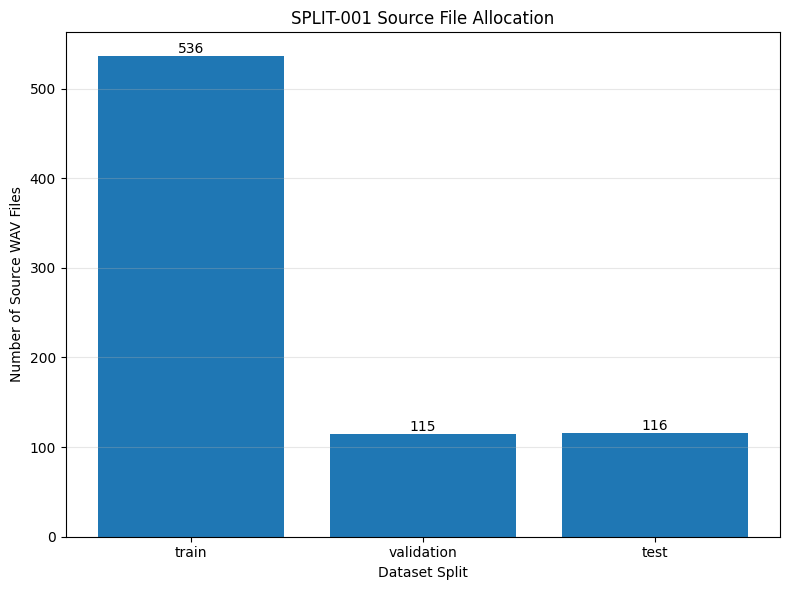

Saved: /content/engine-nvh-deep-learning/results/figures/split_design/01_split_file_counts.png


In [16]:
# Plot file counts by split
fig, ax = plt.subplots(
    figsize=(8, 6)
)

ordered_counts = (
    file_split["split"]
    .value_counts()
    .reindex(
        [
            "train",
            "validation",
            "test",
        ]
    )
)

bars = ax.bar(
    ordered_counts.index,
    ordered_counts.values,
)

ax.set_title(
    "SPLIT-001 Source File Allocation"
)

ax.set_xlabel("Dataset Split")
ax.set_ylabel("Number of Source WAV Files")

ax.grid(
    True,
    axis="y",
    alpha=0.3,
)

for bar, count in zip(
    bars,
    ordered_counts.values,
):
    ax.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height(),
        str(count),
        ha="center",
        va="bottom",
    )

fig.tight_layout()

output_path = (
    SPLIT_FIGURE_DIR
    / "01_split_file_counts.png"
)

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print(f"Saved: {output_path}")

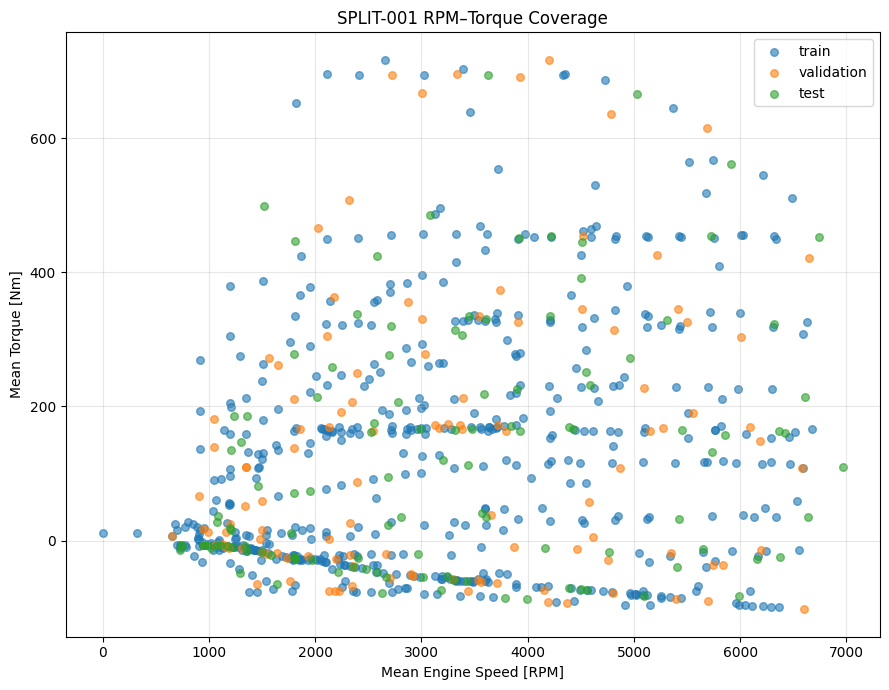

In [17]:
# Plot RPM–torque operating coverage
# This is the most important split-design figure.

# Look for obvious holes such as:
  # Test set containing an RPM region absent from training.
  # Validation set missing high-torque conditions.
  # Entire operating clusters appearing only in one split.

# If the coverage looks reasonable, keep the split.
# Do not keep re-randomizing until you get a visually prettier split.
# That becomes hidden selection bias.

fig, ax = plt.subplots(
    figsize=(9, 7)
)

for split_name in [
    "train",
    "validation",
    "test",
]:

    subset = file_split.loc[
        file_split["split"]
        == split_name
    ]

    ax.scatter(
        subset["rpm_mean"],
        subset["torque_mean_nm"],
        s=30,
        alpha=0.60,
        label=split_name,
    )

ax.set_title(
    "SPLIT-001 RPM–Torque Coverage"
)

ax.set_xlabel(
    "Mean Engine Speed [RPM]"
)

ax.set_ylabel(
    "Mean Torque [Nm]"
)

ax.grid(
    True,
    alpha=0.3,
)

ax.legend()

fig.tight_layout()

output_path = (
    SPLIT_FIGURE_DIR
    / "02_rpm_torque_split_coverage.png"
)

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

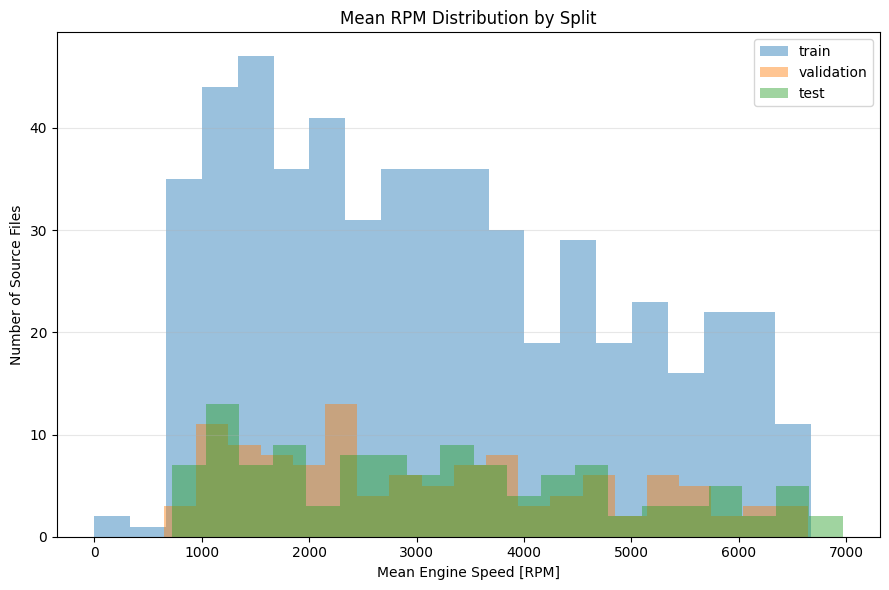

In [18]:
# Plot RPM distributions

fig, ax = plt.subplots(
    figsize=(9, 6)
)

for split_name in [
    "train",
    "validation",
    "test",
]:

    values = file_split.loc[
        file_split["split"]
        == split_name,
        "rpm_mean",
    ]

    ax.hist(
        values,
        bins=20,
        alpha=0.45,
        label=split_name,
    )

ax.set_title(
    "Mean RPM Distribution by Split"
)

ax.set_xlabel(
    "Mean Engine Speed [RPM]"
)

ax.set_ylabel(
    "Number of Source Files"
)

ax.grid(
    True,
    axis="y",
    alpha=0.3,
)

ax.legend()

fig.tight_layout()

output_path = (
    SPLIT_FIGURE_DIR
    / "03_rpm_distribution_by_split.png"
)

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

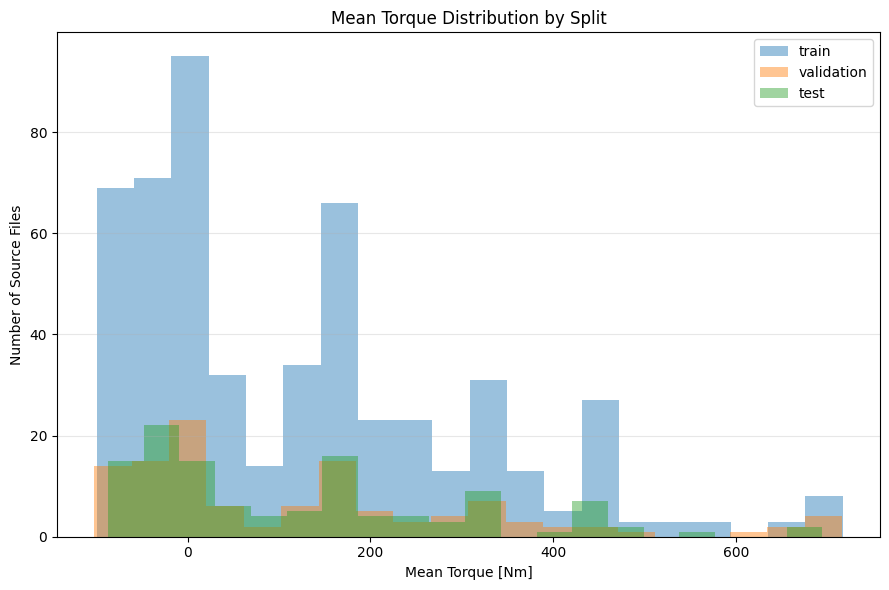

In [19]:
# Plot torque distributions

fig, ax = plt.subplots(
    figsize=(9, 6)
)

for split_name in [
    "train",
    "validation",
    "test",
]:

    values = file_split.loc[
        file_split["split"]
        == split_name,
        "torque_mean_nm",
    ]

    ax.hist(
        values,
        bins=20,
        alpha=0.45,
        label=split_name,
    )

ax.set_title(
    "Mean Torque Distribution by Split"
)

ax.set_xlabel(
    "Mean Torque [Nm]"
)

ax.set_ylabel(
    "Number of Source Files"
)

ax.grid(
    True,
    axis="y",
    alpha=0.3,
)

ax.legend()

fig.tight_layout()

output_path = (
    SPLIT_FIGURE_DIR
    / "04_torque_distribution_by_split.png"
)

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

In [20]:
# Save file_split_v001.csv

FILE_SPLIT_PATH = (
    SPLIT_DIR
    / "file_split_v001.csv"
)

file_split.to_csv(
    FILE_SPLIT_PATH,
    index=False,
)

print(
    f"Frozen file-level split saved to:\n"
    f"{FILE_SPLIT_PATH}"
)

Frozen file-level split saved to:
/content/engine-nvh-deep-learning/data/splits/file_split_v001.csv


In [21]:
# Re-load it once and validate
# Never assume saving worked.

split_check = pd.read_csv(
    FILE_SPLIT_PATH
)

assert len(split_check) == len(
    file_split
)

assert (
    split_check["file_id"]
    .is_unique
)

assert set(
    split_check["split"]
) == {
    "train",
    "validation",
    "test",
}

print(
    "PASS: file_split_v001.csv "
    "reloaded successfully."
)

PASS: file_split_v001.csv reloaded successfully.


In [23]:
# Create split_v001.yaml
# This is the authoritative specification explaining how the split was created.
# You can generate it directly from the notebook.

import yaml
from datetime import date


split_config = {
    "specification": {
        "split_version": "SPLIT-001",
        "status": "frozen",
        "created_date": date.today().isoformat(),
        "dataset_subset": "A_full_set",
    },

    "population": {
        "source_level": "original_wav_file",
        "eligibility": {
            "file_readable": True,
            "quality_flag": "pass",
            "rpm_mean_required": True,
            "torque_mean_nm_required": True,
        },
    },

    "fractions": {
        "train": TRAIN_FRACTION,
        "validation": VALIDATION_FRACTION,
        "test": TEST_FRACTION,
    },

    "randomization": {
        "primary_seed": RANDOM_SEED,
        "secondary_seed": RANDOM_SEED + 1,
    },

    "stratification": {
        "method": "joint_quantile_bins",
        "variables": [
            "rpm_mean",
            "torque_mean_nm",
        ],
        "selected_bins_per_variable":
            int(selected_bin_count),
    },

    "leakage_control": {
        "grouping_unit": "file_id",
        "all_windows_from_parent_file":
            "inherit_parent_split",
        "parent_file_may_span_splits":
            False,
    },

    "test_policy": {
        "frozen_after_creation": True,
        "use_for_model_selection": False,
        "use_for_hyperparameter_tuning": False,
        "use_for_final_evaluation": True,
    },
}


SPLIT_CONFIG_PATH = (
    CONFIG_DIR
    / "split_v001.yaml"
)

with open(
    SPLIT_CONFIG_PATH,
    "w",
) as file:

    yaml.safe_dump(
        split_config,
        file,
        sort_keys=False,
    )


print(
    f"Saved:\n{SPLIT_CONFIG_PATH}"
)

# Inspecting it
with open(
    SPLIT_CONFIG_PATH,
    "r",
) as file:

    print(file.read())

Saved:
/content/engine-nvh-deep-learning/configs/split_v001.yaml
specification:
  split_version: SPLIT-001
  status: frozen
  created_date: '2026-08-09'
  dataset_subset: A_full_set
population:
  source_level: original_wav_file
  eligibility:
    file_readable: true
    quality_flag: pass
    rpm_mean_required: true
    torque_mean_nm_required: true
fractions:
  train: 0.7
  validation: 0.15
  test: 0.15
randomization:
  primary_seed: 42
  secondary_seed: 43
stratification:
  method: joint_quantile_bins
  variables:
  - rpm_mean
  - torque_mean_nm
  selected_bins_per_variable: 4
leakage_control:
  grouping_unit: file_id
  all_windows_from_parent_file: inherit_parent_split
  parent_file_may_span_splits: false
test_policy:
  frozen_after_creation: true
  use_for_model_selection: false
  use_for_hyperparameter_tuning: false
  use_for_final_evaluation: true



In [24]:
# Create split_decision_v001.md
# This report explains the engineering reasoning.
# We are generating the initial version automatically using the
# actual calculated split sizes.

train_count = int(
    ordered_counts["train"]
)

validation_count = int(
    ordered_counts["validation"]
)

test_count = int(
    ordered_counts["test"]
)


report_text = f"""# SPLIT-001 Dataset Split Decision

## Decision

The A_full_set source WAV files are divided into training,
validation, and test sets before audio-window generation.

The target fractions are:

- Training: {TRAIN_FRACTION:.0%}
- Validation: {VALIDATION_FRACTION:.0%}
- Test: {TEST_FRACTION:.0%}

The resulting source-file counts are:

- Training: {train_count}
- Validation: {validation_count}
- Test: {test_count}

## Grouping and leakage control

The original WAV file is the grouping unit.

All model windows subsequently generated from one source WAV file
must inherit the split assignment of that source file.

Windows from the same source file are therefore prohibited from
appearing in multiple dataset splits.

## Stratification

The split was stratified using joint quantile bins based on:

- Mean RPM
- Mean torque

The final stratification used {selected_bin_count} bins per
variable.

This was done to maintain broadly similar operating-condition
coverage across training, validation, and test sets.

## Randomization

Primary random seed: {RANDOM_SEED}

Secondary random seed: {RANDOM_SEED + 1}

## Test-set policy

The SPLIT-001 test set is frozen.

It will not be used for:

- Hyperparameter tuning
- Model selection
- Feature-selection decisions
- Early stopping

It is reserved for final model evaluation.

## Limitation

SPLIT-001 tests generalization to unseen source WAV files within
A_full_set. It does not yet represent generalization to an unseen
engine-synthesis family.

A future project stage should evaluate cross-subset generalization
using additional Procedural Engine Sounds subsets.
"""

REPORT_PATH = (
    REPORT_DIR
    / "split_decision_v001.md"
)

REPORT_PATH.write_text(
    report_text,
    encoding="utf-8",
)

print(
    f"Saved:\n{REPORT_PATH}"
)

# SPLIT-001 is not an unseen-engine test.
# It is an unseen-recording/source-file test within A_full_set.

Saved:
/content/engine-nvh-deep-learning/reports/split_decision_v001.md


In [62]:
# Commit SPLIT-001 to GitHub
# After you visually inspect the plots and accept the split

import subprocess

paths_to_add = [
    "requirements.txt",
    "configs/split_v001.yaml",
    "notebooks/03_split_design.ipynb",
    "data/splits/file_split_v001.csv",
    "reports/split_decision_v001.md",
    "results/tables/split_summary_v001.csv",
    "results/figures/split_design",
    "data/README.md",
    "README.md",
]

subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "add",
        *paths_to_add,
    ],
    check=True,
)

CompletedProcess(args=['git', '-C', '/content/engine-nvh-deep-learning', 'add', 'requirements.txt', 'configs/split_v001.yaml', 'notebooks/03_split_design.ipynb', 'data/splits/file_split_v001.csv', 'reports/split_decision_v001.md', 'results/tables/split_summary_v001.csv', 'results/figures/split_design', 'data/README.md', 'README.md'], returncode=0)

In [73]:
# Review before 'commit'

subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "status",
        "--short",
    ],
    check=True,
)

CompletedProcess(args=['git', '-C', '/content/engine-nvh-deep-learning', 'status', '--short'], returncode=0)

In [71]:
# Commit
commit_result = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "commit",
        "-m",
        "Freeze SPLIT-001 dataset split",
    ],
    capture_output=True,
    text=True,
)

print(commit_result.stdout)

if commit_result.stderr:
    print(commit_result.stderr)

if commit_result.returncode != 0:
    raise RuntimeError(
        "Git commit failed. "
        "Review the Git message above."
    )

print(
    "\nPASS: SPLIT-001 committed successfully."
)

[main b945164] Freeze SPLIT-001 dataset split
 8 files changed, 875 insertions(+)
 create mode 100644 configs/split_v001.yaml
 create mode 100644 data/splits/file_split_v001.csv
 create mode 100644 reports/split_decision_v001.md
 create mode 100644 results/figures/split_design/01_split_file_counts.png
 create mode 100644 results/figures/split_design/02_rpm_torque_split_coverage.png
 create mode 100644 results/figures/split_design/03_rpm_distribution_by_split.png
 create mode 100644 results/figures/split_design/04_torque_distribution_by_split.png
 create mode 100644 results/tables/split_summary_v001.csv


PASS: SPLIT-001 committed successfully.


In [75]:
# Push

current_branch = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "branch",
        "--show-current",
    ],
    capture_output=True,
    text=True,
    check=True,
).stdout.strip()

print(
    f"Current branch: {current_branch}"
)

push_result = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "push",
        "-u",
        "origin",
        current_branch,
    ],
    capture_output=True,
    text=True,
)

print(push_result.stdout)

if push_result.stderr:
    print(push_result.stderr)

if push_result.returncode != 0:
    raise RuntimeError(
        "Git push failed. "
        "Review the output above."
    )

print(
    "\nPASS: SPLIT-001 pushed to GitHub."
)


Current branch: main
Branch 'main' set up to track remote branch 'main' from 'origin'.

To https://github.com/vaibhavjiyer87/engine-nvh-deep-learning.git
   e4dce36..b945164  main -> main


PASS: SPLIT-001 pushed to GitHub.
